# Limpieza y estandarización de datos
## Índice
* [Inspección inicial de los datos](#Inspección-inicial-de-los-datos)
    * [Metodo `info()`](#Metodo-`info()`)
    * [Metodo `describe()`](#Metodo-`describe()`)
    * [Método `value_counts()`](#Método-`value_counts()`)
* [Bases sobre estadística descriptiva](#Bases-sobre-estadística-descriptiva)
    * [Media y mediana](#Media-y-mediana)
    * [Desviación típica](#Desviación-típica)
    * [Percentiles](#Percentiles)
    * [Moda](#Moda)
* [Valores faltantes](#Valores-faltantes)
    * [Detección de valores faltantes](#Detección-de-valores-faltantes)
    * [Manejo de valores faltantes](#Manejo-de-valores-faltantes)
* [Manejo de duplicados](#Manejo-de-duplicados)
    * [Método `duplicated()`](#Método-`duplicated()`)
    * [Método `drop_duplicates()`](#Método-`drop_duplicates()`)
    * [Método `unique()`](#Método-`unique()`)
    * [Método `nunique()`](#Método-`nunique()`)
* [Detección y tratamiento de *outliers*](#Detección-y-tratamiento-de-*outliers*)
    * [¿Qué son los *outliers*?](#¿Qué-son-los-*outliers*?)
    * [Por qué son importantes los *outliers*?](#Por-qué-son-importantes-los-*outliers*?)
    * [Tipos de outliers](#Tipos-de-outliers)
    * [Métodos de detección](#Métodos-de-detección)
        * [Método del rango intercuartílico (IQR)](#Método-del-rango-intercuartílico-(IQR))
        * [Método de la desviación estándar o puntuación z (*z score*)](#Método-de-la-desviación-estándar-o-puntuación-z-(*z-score*))T


In [36]:
import pandas as pd
import numpy as np

## Inspección inicial de los datos
La librería pandas proporciona métodos para inspeccionar los datos, como `head()`, `info()`, `describe()`, y `value_counts()`. Estos métodos permiten obtener una visión general de los datos, identificar valores faltantes, determinar tipos de datos y distribuciones y detección de valores atípicos.
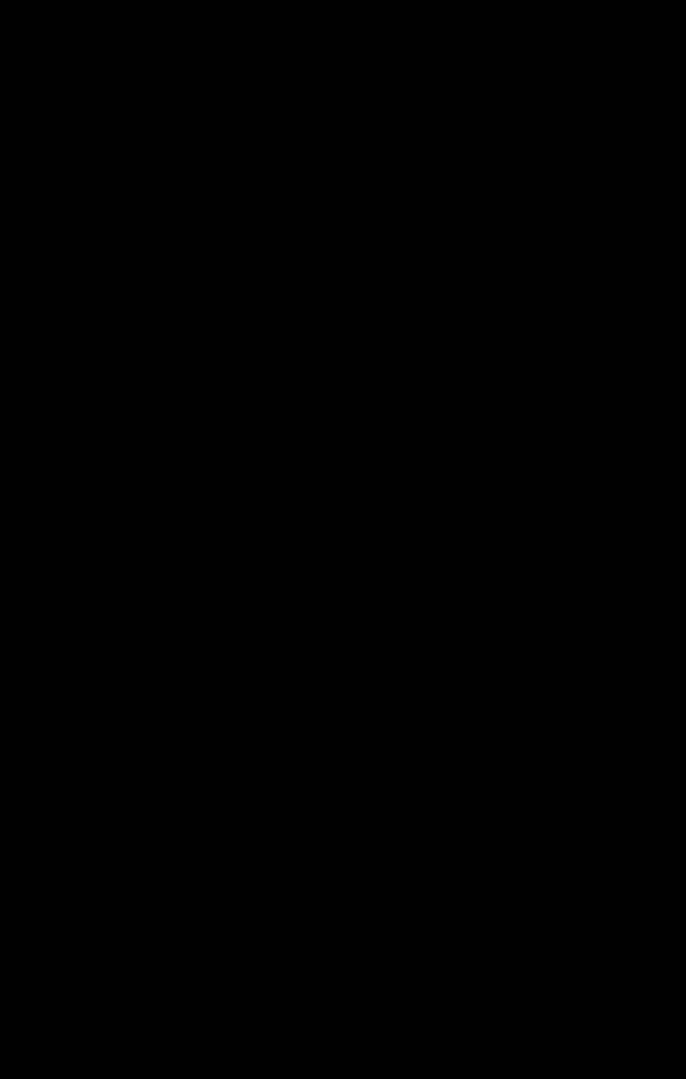

In [37]:
# DataFrame con valores diversos para inspección
dfEjemplo = pd.DataFrame({
    'cod_alumno': [1, 2, None, 4],
    'grupo': ['a', None, 'c', 'd'],
    'altura': [1.78, 1.89, 1.93, None]
})
dfEjemplo

,cod_alumno,grupo,altura
0,1.0,a,1.78
1,2.0,None,1.89
2,NaN,c,1.93
3,4.0,d,NaN


### Metodo `info()`
El método `info()` proporciona un resumen de la estructura del DataFrame, incluyendo el número de entradas, el número de valores no nulos y el tipo de datos de cada columna. Esto es útil para identificar columnas con valores faltantes y para entender la composición de los datos.

In [38]:
dfEjemplo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   cod_alumno  3 non-null      float64
 1   grupo       3 non-null      object 
 2   altura      3 non-null      float64
dtypes: float64(2), object(1)
memory usage: 228.0+ bytes


### Metodo `describe()`
El método `describe()` ofrece estadísticas descriptivas para las columnas numéricas, como la media, la desviación estándar, los valores mínimos y máximos, y los percentiles. Esto ayuda a identificar posibles valores atípicos y a comprender la distribución de los datos.

In [39]:
dfEjemplo.describe()

,cod_alumno,altura
count,3.000000,3.000000
mean,2.333333,1.866667
std,1.527525,0.077675
min,1.000000,1.780000
25%,1.500000,1.835000
50%,2.000000,1.890000
75%,3.000000,1.910000
max,4.000000,1.930000


En el ejemplo anterior, la columna `B` contiene valores de tipo objeto (cadenas de texto), por lo que `describe()` no proporciona estadísticas numéricas para esa columna.

Usando el parámetro `include='all'` en el método `describe()`, se pueden obtener estadísticas descriptivas para todas las columnas, incluyendo las de tipo objeto. Esto proporciona información sobre la cantidad de valores únicos, el valor más frecuente (top) y su frecuencia (freq) para las columnas de tipo objeto.


In [40]:
dfEjemplo.describe(include='all')


,cod_alumno,grupo,altura
count,3.000000,3,3.000000
unique,NaN,3,NaN
top,NaN,a,NaN
freq,NaN,1,NaN
mean,2.333333,NaN,1.866667
std,1.527525,NaN,0.077675
min,1.000000,NaN,1.780000
25%,1.500000,NaN,1.835000
50%,2.000000,NaN,1.890000
75%,3.000000,NaN,1.910000


El parámetro `percentiles` permite especificar los percentiles que se desean calcular. Por ejemplo, `percentiles=[0.25, 0.5, 0.75]` calculará el primer cuartil (25%), la mediana (50%) y el tercer cuartil (75%) para las columnas numéricas.
Pero podemos indicar otros rangos.

Ejemplo:

In [41]:
dfEjemplo.describe(percentiles=[0.33,0.66])

,cod_alumno,altura
count,3.000000,3.000000
mean,2.333333,1.866667
std,1.527525,0.077675
min,1.000000,1.780000
33%,1.660000,1.852600
50%,2.000000,1.890000
66%,2.640000,1.902800
max,4.000000,1.930000


Normalmente siempre aparece el percentil del 50% (mediana) en el resultado de `describe()`, incluso si no se especifica en el parámetro `percentiles`. Esto se debe a que la mediana es una medida de tendencia central importante y se incluye por defecto en las estadísticas descriptivas proporcionadas por `describe()`.

### Método `value_counts()`
El método `value_counts()` se utiliza para contar la frecuencia de cada valor único en una columna. Esto es especialmente útil para columnas de tipo objeto (cadenas de texto) o categóricas, ya que permite identificar la distribución de los valores en esa columna. En el ejemplo anterior, se puede usar `value_counts()` para obtener la frecuencia de cada valor en la columna `B`.

In [42]:
dfEjemplo['grupo'].value_counts()

grupo
a    1
c    1
d    1
Name: count, dtype: int64

`value`_counts()` dispone de un parámetro llamado `dropna` que, si se establece en `False`, incluirá los valores faltantes en el conteo. Esto es útil para obtener una visión completa de la distribución de los datos, incluyendo la cantidad de valores faltantes.

In [43]:
dfEjemplo['grupo'].value_counts(dropna=False)

grupo
a       1
None    1
c       1
d       1
Name: count, dtype: int64

## Bases sobre estadística descriptiva
La estadística descriptiva es una rama de la estadística que se encarga de resumir y describir las características principales de un conjunto de datos. Esto se logra a través de medidas de tendencia central, como la media, la mediana y la moda, y medidas de dispersión, como la desviación estándar, el rango y el rango intercuartílico. Estas medidas permiten obtener una visión general de los datos, identificar patrones y detectar posibles valores atípicos. La estadística descriptiva es fundamental para el análisis de datos, ya que proporciona información clave sobre la distribución y la variabilidad de los datos, lo que es esencial para tomar decisiones informadas y realizar análisis más profundos.
### Media y mediana
La media es el promedio de un conjunto de datos, calculado sumando todos los valores y dividiendo por el número total de valores. La mediana es el valor que se encuentra en el medio de un conjunto de datos ordenados. La media es sensible a los valores atípicos, mientras que la mediana es más robusta y no se ve afectada por los valores extremos. Por lo tanto, la mediana puede ser una mejor medida de tendencia central cuando los datos contienen valores atípicos o están sesgados.

In [44]:
dfDatos = pd.DataFrame({
    'id_trabajador': [1, 2, 3, 4, 5],
    'salario': [1200, 1320, 1430, 1540, 25000] # El valor 25000 es un valor atípico que afecta la media
})
media_salario = dfDatos['salario'].mean()
mediana_salario = dfDatos['salario'].median()
print(f"Media del salario: {media_salario}")
print(f"Mediana del salario: {mediana_salario}") # Refleja mejor el salario típico de los trabajadores, ya que no se ve afectada por el valor atípico de 25000

Media del salario: 6098.0
Mediana del salario: 1430.0


### Desviación típica
La desviación típica, también conocida como desviación estándar, es una medida de dispersión que indica cuánto se desvían los valores de un conjunto de datos con respecto a su media. Se calcula de esta forma:
1. Se calcula la media del conjunto de datos.
2. Se resta la media a cada valor del conjunto de datos para obtener las desviaciones individuales.
3. Se elevan al cuadrado las desviaciones individuales para obtener las desviaciones al cuadrado.
4. Se calcula la media de las desviaciones al cuadrado para obtener la varianza.
5. Se toma la raíz cuadrada de la varianza para obtener la desviación típica.

La desviación típica es útil para entender la variabilidad de los datos. Una desviación típica alta indica que los valores se dispersan ampliamente alrededor de la media, mientras que una desviación típica baja indica que los valores están más agrupados cerca de la media. La desviación típica es especialmente útil para comparar la dispersión de diferentes conjuntos de datos o para identificar valores atípicos.

In [45]:
dfDatos = pd.DataFrame({
    "A": [2, 2, 2, 2, 2], # Desviación típica de 0, ya que todos los valores son iguales a la media
    "B": [1, 2, 3, 4, 5], # Desviación típica de aproximadamente 1.58, ya que los valores se dispersan alrededor de la media (3)
    "C": [1, 2, 3, 4, 40] # Desviación típica de aproximadamente 15.17, ya que el valor 40 es un valor atípico que se encuentra muy alejado de la media (10), lo que aumenta significativamente la dispersión de los datos
})
print("Desviación típica de la columna A:", dfDatos["A"].std())
print("Desviación típica de la columna B:", dfDatos["B"].std())
print("Desviación típica de la columna C:", dfDatos["C"].std())

Desviación típica de la columna A: 0.0
Desviación típica de la columna B: 1.5811388300841898
Desviación típica de la columna C: 16.80773631397161


### Percentiles
Los percentiles son medidas que dividen un conjunto de datos ordenados en 100 partes iguales. Así el percentil 25 (Q1, primer cuartil) es el valor que separa el 25% inferior de los datos del 75% superior, el percentil 50 (Q2 o mediana) es el valor que separa el 50% inferior de los datos del 50% superior, y el percentil 75 (Q3) es el valor que separa el 75% inferior de los datos del 25% superior. Los percentiles son útiles para entender la distribución de los datos y para identificar valores atípicos. Por ejemplo, un valor que se encuentra por debajo del percentil 25 o por encima del percentil 75 puede considerarse un valor atípico.

In [46]:
dfDatos = pd.DataFrame({
    'id_trabajador': [1, 2, 3, 4, 5, 6, 7, 8, 9 , 10],
    'salario': [1000, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000]
})
Q1 = dfDatos['salario'].quantile(0.25) # Percentil 25 (primer cuartil)
Q2 = dfDatos['salario'].quantile(0.50) # Percentil 50 (mediana)
Q3 = dfDatos['salario'].quantile(0.75) # Percentil 75 (tercer cuartil)
print(f"Percentil 25 (Q1): {Q1}")
print(f"Percentil 50 (Q2 o mediana): {Q2}")
print(f"Percentil 75 (Q3): {Q3}")


Percentil 25 (Q1): 1325.0
Percentil 50 (Q2 o mediana): 1550.0
Percentil 75 (Q3): 1775.0


### Moda
La moda es la medida de tendencia central que representa el valor o los valores que ocurren con mayor frecuencia en un conjunto de datos. Un conjunto de datos puede tener una moda única (unimodal), varias modas (multimodal) o no tener moda si todos los valores son únicos. La moda es especialmente útil para describir datos categóricos o discretos, ya que indica el valor más común en la distribución de los datos. En algunos casos, la moda puede ser más representativa que la media o la mediana, especialmente cuando los datos contienen valores atípicos o están sesgados.

In [47]:
dfDatos = pd.DataFrame({
    'id_trabajador': [1, 2, 3, 4, 5, 6, 7, 8, 9 , 10],
    'departamento': ['Ventas', 'Marketing', 'Ventas', 'Recursos Humanos', 'Marketing', 'Ventas', 'Recursos Humanos', 'Marketing', 'Ventas', 'Recursos Humanos']
})
moda_departamento = dfDatos['departamento'].mode()
print(f"Moda del dato departamento: {moda_departamento[0]}") # El departamento de Ventas es el más común, ya que aparece 4 veces en el conjunto de datos, mientras que los departamentos de Marketing y Recursos Humanos aparecen 3 veces cada uno.
moda_id_trabajador = dfDatos['id_trabajador'].mode()
print(f"Moda del dato id_trabajador:\n {moda_id_trabajador}") # No hay moda, ya que todos los valores de id_trabajador son únicos y no se repiten, por lo que no hay un valor que ocurra con mayor frecuencia en esa columna.

Moda del dato departamento: Ventas
Moda del dato id_trabajador:
 0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
Name: id_trabajador, dtype: int64


## Valores faltantes
### Detección de valores faltantes
Para detectar valores faltantes, se pueden usar métodos como `isnull()` o `isna()`, que devuelven un DataFrame booleano indicando la presencia de valores faltantes.

In [48]:
dfValoresFaltas = pd.DataFrame({
    'A': [1, 2, None, 4],
    'B': ['a', None, 'c', 'd'],
    'C': [None, None, None, None]
})
print(dfValoresFaltas.isnull())

       A      B     C
0  False  False  True
1  False   True  True
2   True  False  True
3  False  False  True


También se puede usar `sum()` para contar el número de valores faltantes en cada columna.

In [49]:
print(dfValoresFaltas.isnull().sum())

A    1
B    1
C    4
dtype: int64


In [50]:
print(dfValoresFaltas.isna())

       A      B     C
0  False  False  True
1  False   True  True
2   True  False  True
3  False  False  True


Tanto `isnull()` como `isna()` se pueden usar indistintamente para detectar valores faltantes en un DataFrame. Ambos devuelven un DataFrame booleano donde `True` indica la presencia de un valor faltante (NaN) y `False` indica la ausencia de un valor faltante. Por lo tanto, no hay diferencia funcional entre ellos, y puedes usar cualquiera de los dos según tu preferencia.

### Manejo de valores faltantes
Pandas ofrece varias formas de manejar los valores faltantes, como `dropna()` para eliminar filas o columnas con valores faltantes, y `fillna()` para rellenar los valores faltantes con un valor específico.

El método `dropna()` se puede usar para eliminar filas o columnas que contienen valores faltantes. Por ejemplo, `df.dropna()` eliminará todas las filas que contengan al menos un valor faltante, mientras que `df.dropna(axis=1)` eliminará todas las columnas que contengan al menos un valor faltante.

In [51]:
dfAlgunasFaltas = pd.DataFrame({
    'A': [1, 2, 3, 4],
    'B': ['a', None, 'c', 'd'],
    'C': [10, None, None, 20]})
dfAlgunasFaltas.dropna() # Solo hay dos filas sin valores faltantes, por lo que solo se mantienen esas filas

,A,B,C
0,1,a,10.0
3,4,d,20.0


In [52]:
dfAlgunasFaltas.dropna(axis=1) # Solo hay una columna sin valores faltantes, por lo que solo se mantiene esa columna

,A
0,1
1,2
2,3
3,4



El método `fillna()` se puede usar para rellenar los valores faltantes con un valor específico. Por ejemplo, `df.fillna(0)` reemplazará todos los valores faltantes con 0.

In [53]:
dfCopia = dfValoresFaltas.copy() # Para no modificar el DataFrame original
dfCopia["A"]=dfCopia["A"].fillna(0) # Rellenar los valores faltantes en la columna A con 0
dfCopia

,A,B,C
0,1.0,a,None
1,2.0,None,None
2,0.0,c,None
3,4.0,d,None


## Manejo de duplicados
Los duplicados son filas que contienen los mismos valores en todas las columnas. La presencia de duplicados puede afectar el análisis de datos y los resultados de los modelos de machine learning, por lo que es importante detectarlos y tratarlos adecuadamente.
### Método `duplicated()`
El método `duplicated()` devuelve un DataFrame booleano indicando la presencia de filas duplicadas. Ese DataFrame nos puede servir como filtro para obtener solo las filas no duplicadas de un DataFrame

In [54]:
dfDuplicados = pd.DataFrame({
    'A': [1, 1, 2, 3],
    'B': ['a', 'a', 'b', 'c'],
    'C': [10, 10, 20, 30]
})
print(dfDuplicados.duplicated()) # En la segunda fila se detecta un duplicado, ya que es idéntica a la primera fila

0    False
1     True
2    False
3    False
dtype: bool


In [55]:
filtro = ~dfDuplicados.duplicated() # Filtro para obtener solo las filas no duplicadas
dfSinDuplicados = dfDuplicados[filtro] # Aplicar el filtro al DataFrame
print(dfSinDuplicados)

   A  B   C
0  1  a  10
2  2  b  20
3  3  c  30


Este método posee los siguientes parámetros:
* `keep`: Este parámetro determina qué filas duplicadas se consideran como duplicados. Puede tomar los siguientes valores:
  * `'first'`: Mantiene la primera aparición de cada fila duplicada y marca las siguientes como duplicados (valor predeterminado).
  * `'last'`: Mantiene la última aparición de cada fila duplicada y marca las anteriores como duplicados.
  * `False`: Marca todas las filas duplicadas como duplicados, sin mantener ninguna de ellas.
* `subset`: Este parámetro permite especificar un subconjunto de columnas para considerar al identificar duplicados. Si se proporciona una lista de columnas, solo se considerarán esas columnas para determinar si una fila es un duplicado. Si no se especifica, se considerarán todas las columnas del DataFrame para identificar duplicados.
* `inplace`: Este parámetro, si se establece en `True`, modificará el DataFrame original eliminando las filas duplicadas en lugar de devolver un nuevo DataFrame. Si se establece en `False` (valor predeterminado), se devolverá un nuevo DataFrame con las filas duplicadas eliminadas, y el DataFrame original permanecerá sin cambios.

### Método `drop_duplicates()`
El método `drop_duplicates()` se utiliza para eliminar las filas duplicadas de un DataFrame. Por defecto, `drop_duplicates()` mantiene la primera aparición de cada fila duplicada y elimina las siguientes.

In [56]:
dfDuplicados.drop_duplicates() # Se elimina la segunda fila, ya que es un duplicado de la primera fila

,A,B,C
0,1,a,10
2,2,b,20
3,3,c,30


### Método `unique()`
El método `unique()` se utiliza para obtener los valores únicos de una columna específica. Esto es útil para identificar los valores distintos presentes en una columna y para detectar posibles duplicados en esa columna. Los valores únicos se devuelven como un array de NumPy.


Este método también tiene los mismos parámetros que `duplicated()`, como `keep` y `subset`, que permiten controlar qué filas duplicadas se eliminan y qué columnas se consideran para identificar duplicados.

In [57]:
duplicados = dfDuplicados["A"].unique()
print(duplicados) # Devuelve los valores únicos de la columna A, que son 1, 2 y 3

[1 2 3]


### Método `nunique()`
El método `nunique()` se utiliza para contar el número de valores únicos en una columna específica. Esto es útil para obtener una visión general de la diversidad de valores presentes en una columna y para detectar posibles duplicados. El resultado es un número entero que representa la cantidad de valores únicos en la columna.

In [58]:
print("Valores diferentes en la columna A:",dfDuplicados["A"].nunique()) # Devuelve el número de valores únicos en la columna A, que es 3
print("Valores duplicados en la columna A:",dfDuplicados["A"].count()-dfDuplicados["A"].nunique()) # Devuelve el número de valores duplicados en la columna A, que es 1 (el valor 1 se repite dos veces)

Valores diferentes en la columna A: 3
Valores duplicados en la columna A: 1


## Detección y tratamiento de *outliers*
### ¿Qué son los *outliers*?
Los *outliers* son valores que se encuentran significativamente alejados de la mayoría de los datos. Por lo tanto no mantienen el patrón general de distribución de los datos.

Los outliers pueden deberse a:
* Errores de medición o entrada de datos
* Variabilidad natural en los datos
* Condiciones especiales o eventos raros
* Errores al registrar o procesar los datos

### Por qué son importantes los *outliers*?
Los *outliers* pueden tener un impacto significativo en el análisis de datos, ya que pueden distorsionar las estadísticas descriptivas, afectar la distribución de los datos y sesgar los resultados de los modelos de machine learning. Por lo tanto, es importante detectar y tratar los *outliers* adecuadamente para obtener resultados más precisos y confiables en el análisis de datos.

### Tipos de outliers
* **Por error de medición o entrada de datos**: Estos *outliers* pueden ser causados por errores humanos, fallos en los instrumentos de medición o problemas en el proceso de recolección de datos. Por ejemplo, un valor de temperatura registrado como 1000 grados Celsius en lugar de 10 grados Celsius sería un *outlier* causado por un error de medición.
* **Procedente de datos reales**: Estos *outliers* pueden ser causados por eventos raros o condiciones especiales que ocurren en el mundo real. Por ejemplo, un valor de ingresos extremadamente alto en un conjunto de datos de ingresos podría ser un *outlier* procedente de datos reales, ya que podría representar a una persona con ingresos excepcionalmente altos.

### Métodos de detección
Existen varios métodos para detectar *outliers*, como el método de los cuartiles, el método de la desviación estándar y el método de la puntuación z. Estos métodos se basan en diferentes enfoques para identificar valores que se encuentran significativamente alejados de la mayoría de los datos.
#### Método del rango intercuartílico (IQR)
El método del **rango intercuartílico** (**IQR**) es un enfoque común para detectar *outliers* en un conjunto de datos. El IQR se calcula como la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1) de los datos. Los *outliers* se identifican como valores que se encuentran por debajo de Q1 - 1.5 * IQR o por encima de Q3 + 1.5 * IQR.

In [59]:
dfOutliers = pd.DataFrame({
    'A': [1, 2, 3, 4, 5, 100], # 100 es un outlier
    'B': [10, 20, 30, 40, 50, 60], # No hay outliers
    'C': [5, 6, 7, 8, 9, 10] # No hay outliers
})
Q1 = dfOutliers['A'].quantile(0.25) # Primer cuartil
Q3 = dfOutliers['A'].quantile(0.75) # Tercer cuartil
IQR = Q3 - Q1 # Rango intercuartílico
filtroOutliers = (dfOutliers['A'] < Q1 - 1.5 * IQR) | (dfOutliers['A'] > Q3 + 1.5 * IQR) # Filtro para identificar los outliers
outliers = dfOutliers[filtroOutliers] # Filtrar los outliers
print("Outliers de la columna 'A'\n",outliers['A']) # Imprimir los valores de la columna A que son outliers, en este caso el valor 100

Q1 = dfOutliers['B'].quantile(0.25) # Primer cuartil
Q3 = dfOutliers['B'].quantile(0.75) # Tercer cuartil
IQR = Q3 - Q1 # Rango intercuartílico
filtroOutliers = (dfOutliers['B'] < Q1 - 1.5 * IQR) | (dfOutliers['B'] > Q3 + 1.5 * IQR) # Filtro para identificar los outliers
outliers = dfOutliers[filtroOutliers] # Filtrar los outliers
print("\nOutliers de la columna 'B'\n",outliers['B']) # No hay outliers en la columna B, por lo que no se imprimirá ningún valor

Outliers de la columna 'A'
 5    100
Name: A, dtype: int64

Outliers de la columna 'B'
 Series([], Name: B, dtype: int64)


#### Método de la desviación estándar o puntuación z (*z score*)
El método de la **desviación estándar** o ***z score*** es otro enfoque para detectar *outliers* en un conjunto de datos. Se llama puntuación z (*z score*) a la cantidad de desviaciones estándar que un valor se encuentra por encima o por debajo de la media. Por ejemplo, un valor con una puntuación z de 3 se encuentra a 3 desviaciones estándar por encima de la media, mientras que un valor con una puntuación z de -2 se encuentra a 2 desviaciones estándar por debajo de la media.

Los *outliers* se identifican como valores que se encuentran a más de 3 desviaciones estándar de la media. Es decir, un valor se considera un *outlier* si es menor que la media menos 3 veces la desviación estándar o mayor que la media más 3 veces la desviación estándar.

In [60]:
dfOutliers = pd.DataFrame({
    'A': [1, 2, 3, 4, 5, 100], # 100 es un outlier
    'B': [10, 20, 30, 40, 50, 60], # No hay outliers
    'C': [5, 6, 7, 8, 9, 10] # No hay outliers
})
media_A = dfOutliers['A'].mean() # Media de la columna A
desviacion_A = dfOutliers['A'].std() # Desviación estándar de la columna A
filtroOutliers = (dfOutliers['A'] < media_A - 3 * desviacion_A) | (dfOutliers['A'] > media_A + 3 * desviacion_A) # Filtro para identificar los outliers
outliers = dfOutliers[filtroOutliers] # Filtrar los outliers
print("Outliers de la columna 'A'\n",outliers['A']) # Imprimir los valores de la columna A que son outliers, en este caso no se detecta el valor 100 como un outlier, ya que no se encuentra a más de 3 desviaciones estándar de la media

Outliers de la columna 'A'
 Series([], Name: A, dtype: int64)


In [61]:
dfOutliers = pd.DataFrame({
    'A': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 100], # 100 es un outlier
    'B': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130], # No hay outliers
    'C': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] # No hay outliers
})
media_A = dfOutliers['A'].mean() # Media de la columna A
print(media_A)
desviacion_A = dfOutliers['A'].std() # Desviación estándar de la columna A
print(desviacion_A)
filtroOutliers = (dfOutliers['A'] < media_A - 3 * desviacion_A) | (dfOutliers['A'] > media_A + 3 * desviacion_A) # Filtro para identificar los outliers
outliers = dfOutliers[filtroOutliers] # Filtrar los outliers
print("Outliers de la columna 'A'\n",outliers['A']) # Imprimir los valores de la columna A que son outliers, en este caso se detecta el valor 100 como un outlier, ya que se encuentra a más de 3 desviaciones estándar de la media (media_A = 14.23 y desviacion_A = 27.39, por lo que 100 > media_A + 3 * desviacion_A)

13.692307692307692
26.160990728514772
Outliers de la columna 'A'
 12    100
Name: A, dtype: int64
